In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
#set the random seed for reproducibility
np.random.seed(0)

In [13]:
#define the popolation distribution: uniform distrubution is used here
population_size=1000
population_data=np.random.uniform(low=0, high=100, size=population_size)

In [14]:
#parameters for simulation
sample_size= 30
num_samples=1000

# Function to simulate the CLT process
def simulate_clt(population_data, sample_size, num_samples):
    sample_means = []
    for _ in range(num_samples):
        sample = np.random.choice(population_data, size=sample_size, replace=False)
        sample_means.append(np.mean(sample))
    return sample_means

#simulate CLT
sample_means=simulate_clt(population_data,sample_size,num_samples)


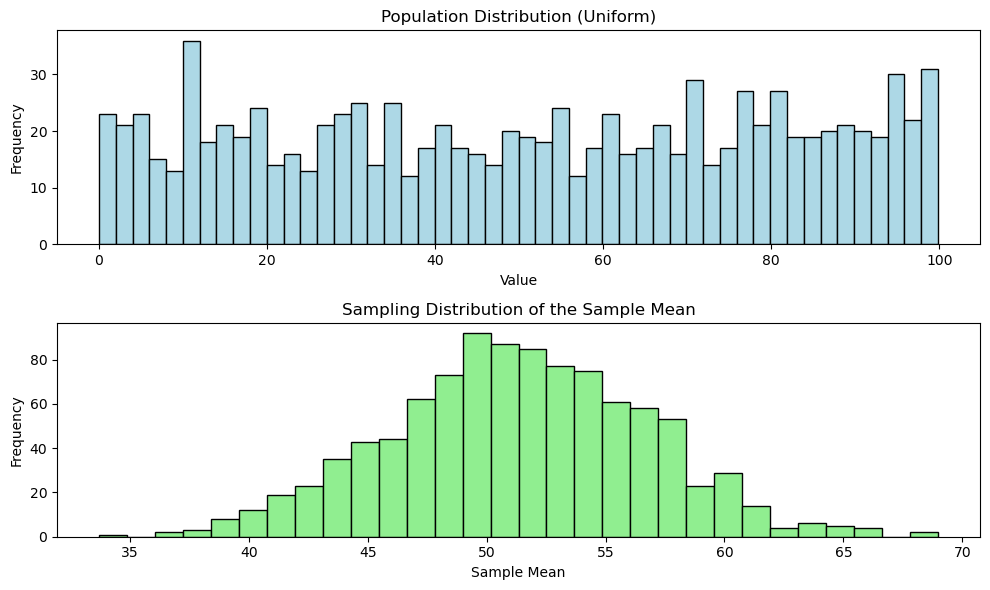

In [15]:
#plot the results
plt.figure(figsize=(10,6))
#plot the population distribution
plt.subplot(2,1,1)
plt.hist(population_data, bins=50, color='lightblue', edgecolor='black')
plt.title('Population Distribution (Uniform)')
plt.xlabel('Value')
plt.ylabel('Frequency')

#plot the distribution of sample means
plt.subplot(2, 1, 2)
plt.hist(sample_means, bins=30, color='lightgreen', edgecolor='black')
plt.title('Sampling Distribution of the Sample Mean')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

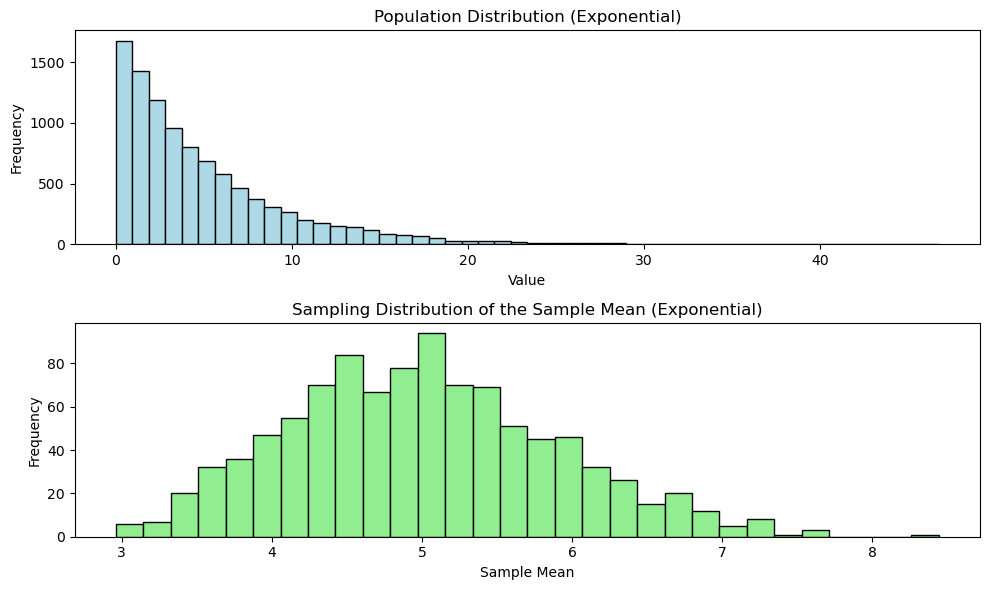

In [16]:
# Problem: Sampling from an Exponential Distribution
population_data_exp = np.random.exponential(scale=5, size=10000) # Exponential distribution with mean=5
# Simulate CLT for Exponential distribution
sample_means_exp = simulate_clt(population_data_exp, sample_size=30, num_samples=1000)
# Plot the results
plt.figure(figsize=(10, 6))
# Population Distribution (Exponential)
plt.subplot(2, 1, 1)
plt.hist(population_data_exp, bins=50, color='lightblue', edgecolor='black')
plt.title('Population Distribution (Exponential)')
plt.xlabel('Value')
plt.ylabel('Frequency')
# Sampling Distribution of Sample Mean
plt.subplot(2, 1, 2)
plt.hist(sample_means_exp, bins=30, color='lightgreen', edgecolor='black')
plt.title('Sampling Distribution of the Sample Mean (Exponential)')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

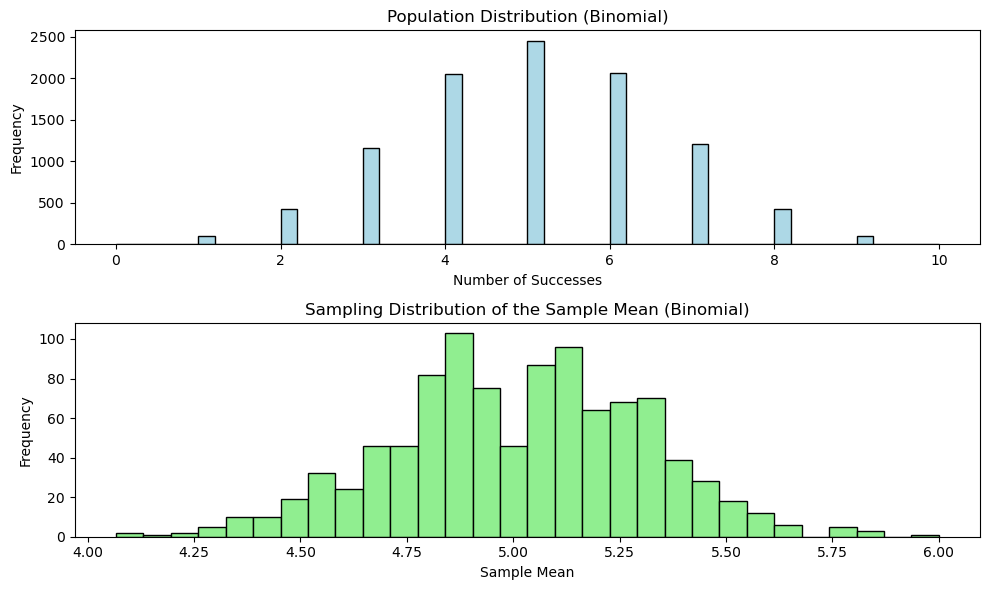

In [17]:
# Problem: Sampling from a Binomial Distribution
population_data_binom = np.random.binomial(n=10, p=0.5, size=10000) # Binomial distribution (10 trials, p=0.5)
# Simulate CLT for Binomial distribution
sample_means_binom = simulate_clt(population_data_binom, sample_size=30, num_samples=1000)
# Plot the results
plt.figure(figsize=(10, 6))
# Population Distribution (Binomial)
plt.subplot(2, 1, 1)
plt.hist(population_data_binom, bins=50, color='lightblue', edgecolor='black')
plt.title('Population Distribution (Binomial)')
plt.xlabel('Number of Successes')
plt.ylabel('Frequency')
# Sampling Distribution of Sample Mean
plt.subplot(2, 1, 2)
plt.hist(sample_means_binom, bins=30, color='lightgreen', edgecolor='black')
plt.title('Sampling Distribution of the Sample Mean (Binomial)')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

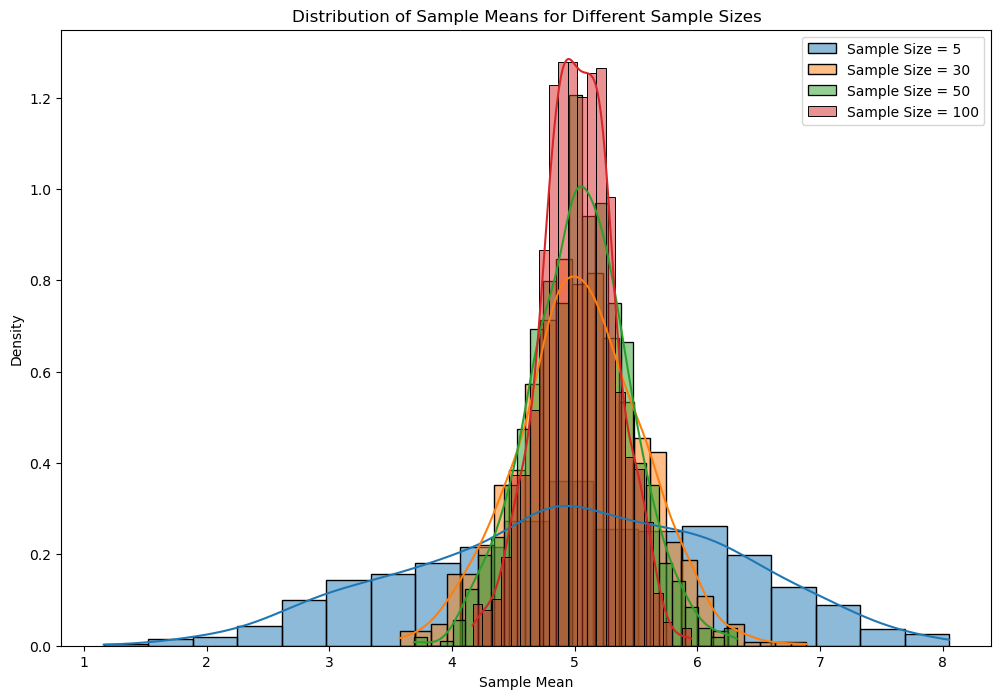

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Step 1: Define the population (Uniform distribution)
population = np.random.uniform(0, 10, 10000)
# Step 2: Define sample sizes and number of samples
sample_sizes = [5, 30, 50, 100] # Different sample sizes
num_samples = 1000 # Number of samples to draw
# Step 3: Collect sample means for each sample size
sample_means = {size: [] for size in sample_sizes}
for size in sample_sizes:
    for _ in range(num_samples):
        sample = np.random.choice(population, size=size, replace=False)
        sample_means[size].append(np.mean(sample))
# Step 4: Plotting the results
plt.figure(figsize=(12, 8))
for size in sample_sizes:
    sns.histplot(sample_means[size], kde=True, label=f'Sample Size = {size}', stat='density')
plt.title('Distribution of Sample Means for Different Sample Sizes')
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.legend()
plt.show()

In [26]:
!mamba install pandas


mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.877 seconds
All requested packages already installed.


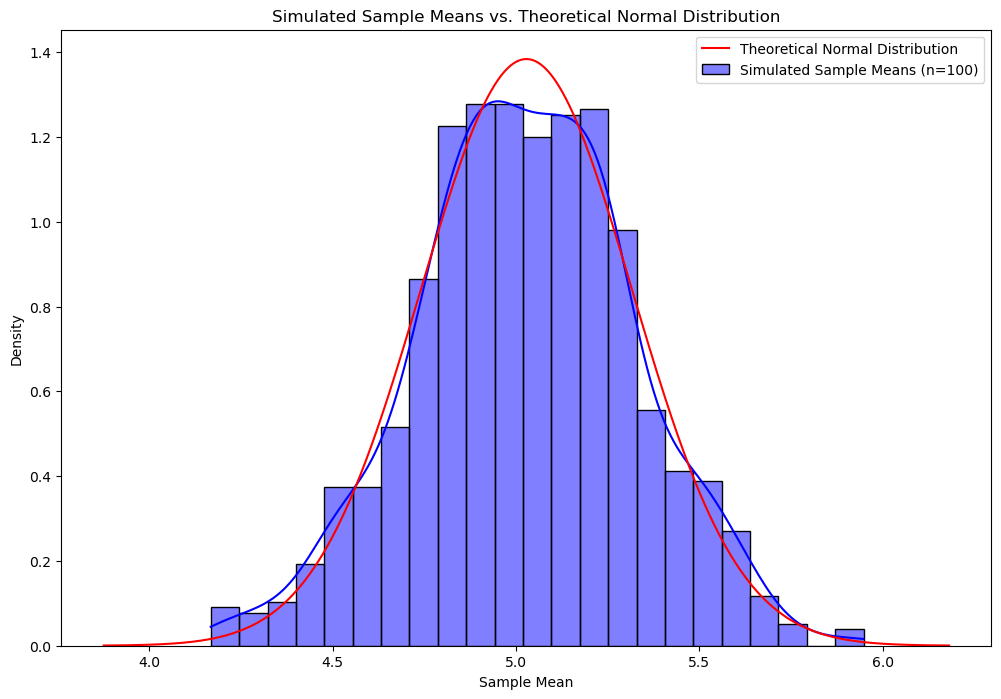

In [27]:
# Population statistics
import numpy as np
population_mean = np.mean(population)
population_std = np.std(population)
# Step 5: Overlay Normal distribution for sample size 100
sample_size = 100
theoretical_std = population_std / np.sqrt(sample_size)
plt.figure(figsize=(12, 8))
sns.histplot(sample_means[100], kde=True, stat='density', color='blue', label='Simulated Sample Means (n=100)')
# Theoretical Normal Distribution
x = np.linspace(population_mean - 4 * theoretical_std, population_mean + 4 * theoretical_std, 1000)
y = (1 / (theoretical_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - population_mean) / theoretical_std) ** 2)
plt.plot(x, y, color='red', label='Theoretical Normal Distribution')
plt.title('Simulated Sample Means vs. Theoretical Normal Distribution')
plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.legend()
plt.show()

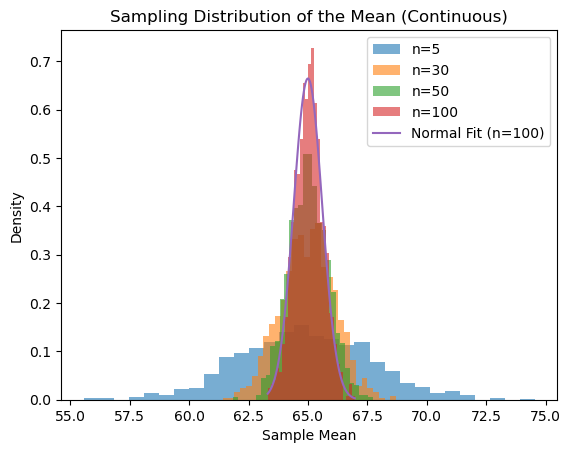

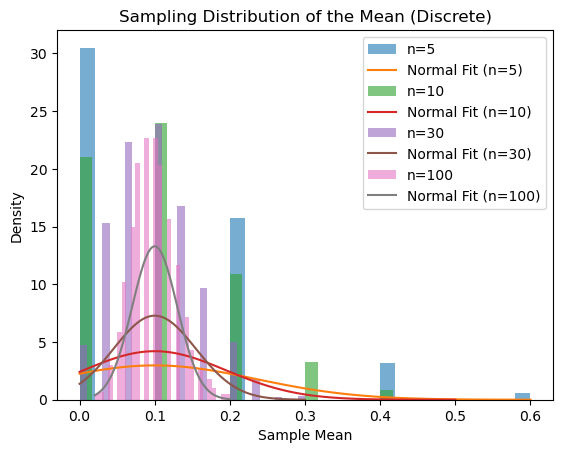

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Set random seed for reproducibility
np.random.seed(42)
# Function to simulate CLT for continuous distribution
def clt_continuous(population_mean, population_std, population_size, sample_sizes, num_samples):
    population = np.random.normal(population_mean, population_std, population_size)
    for n in sample_sizes:
        sample_means = []
        for _ in range(num_samples):
            sample = np.random.choice(population, size=n, replace=False)
            sample_means.append(np.mean(sample))
        # Plotting the sampling distribution of the mean
        plt.hist(sample_means, bins=30, alpha=0.6, density=True, label=f'n={n}')
        # Overlaying a normal distribution
        sampling_std = population_std / np.sqrt(n)
        x = np.linspace(min(sample_means), max(sample_means), 100)
    plt.plot(x, norm.pdf(x, population_mean, sampling_std), label=f'Normal Fit (n={n})')
    plt.title("Sampling Distribution of the Mean (Continuous)")
    plt.xlabel("Sample Mean")
    plt.ylabel("Density")
    plt.legend()
    plt.show()
# Function to simulate CLT for discrete distribution
def clt_discrete(prob, sample_sizes, num_samples):
    population = np.random.choice([0, 1], p=[1 - prob, prob], size=100000)
    for n in sample_sizes:
        sample_means = []
        for _ in range(num_samples):
            sample = np.random.choice(population, size=n, replace=False)
            sample_means.append(np.mean(sample))
        # Plotting the sampling distribution of the mean
        plt.hist(sample_means, bins=30, alpha=0.6, density=True, label=f'n={n}')
        # Overlaying a normal distribution
        sampling_std = np.sqrt(prob * (1 - prob)) / np.sqrt(n)
        sampling_mean = prob
        x = np.linspace(min(sample_means), max(sample_means), 100)
        plt.plot(x, norm.pdf(x, sampling_mean, sampling_std), label=f'Normal Fit (n={n})')
    plt.title("Sampling Distribution of the Mean (Discrete)")
    plt.xlabel("Sample Mean")
    plt.ylabel("Density")
    plt.legend()
    plt.show()
# Continuous distribution example
population_mean = 65
population_std = 6
population_size = 100000
sample_sizes = [5, 30, 50, 100]
num_samples = 1000
clt_continuous(population_mean, population_std, population_size, sample_sizes, num_samples)
# Discrete distribution example
prob_left_handed = 0.1
sample_sizes = [5, 10, 30, 100]
num_samples = 1000
clt_discrete(prob_left_handed, sample_sizes, num_samples)

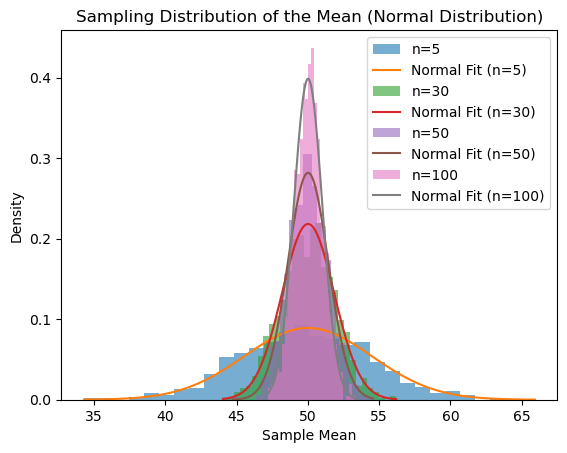

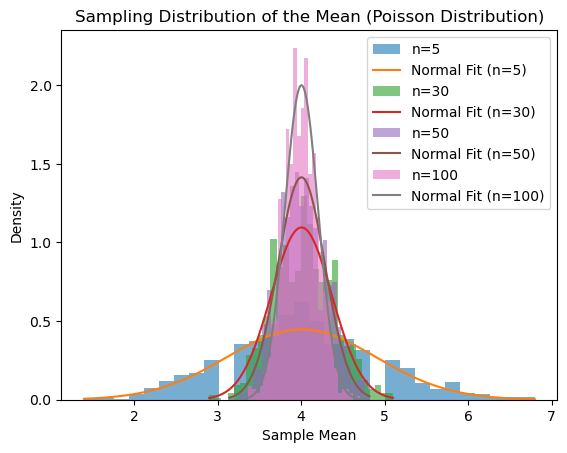

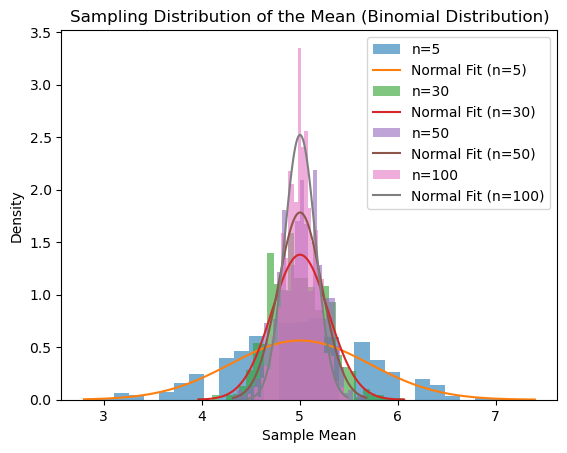

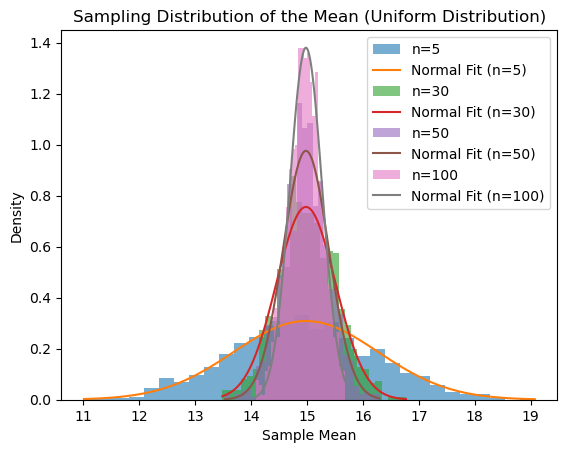

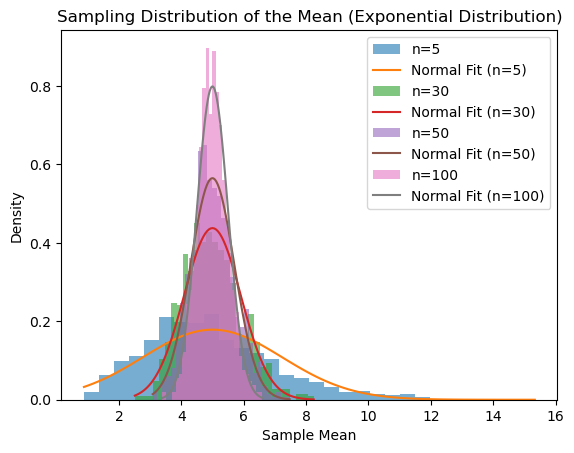

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, poisson, binom

# Set random seed for reproducibility
np.random.seed(42)


# Function to demonstrate CLT for any given distribution
def clt_simulation(population, sample_sizes, num_samples, dist_name):

    for n in sample_sizes:
        sample_means = []

        for _ in range(num_samples):
            sample = np.random.choice(population, size=n, replace=False)
            sample_means.append(np.mean(sample))

        # Plotting the sampling distribution of the mean
        plt.hist(sample_means, bins=30, alpha=0.6, density=True, label=f'n={n}')

        # Overlaying a normal distribution
        sampling_mean = np.mean(population)
        sampling_std = np.std(population) / np.sqrt(n)

        x = np.linspace(min(sample_means), max(sample_means), 100)

        plt.plot(x,
                 norm.pdf(x, sampling_mean, sampling_std),
                 label=f'Normal Fit (n={n})')

    plt.title(f"Sampling Distribution of the Mean ({dist_name})")
    plt.xlabel("Sample Mean")
    plt.ylabel("Density")
    plt.legend()
    plt.show()


# Normal distribution example
population_normal = np.random.normal(loc=50, scale=10, size=100000)
sample_sizes = [5, 30, 50, 100]
num_samples = 1000

clt_simulation(population_normal,
               sample_sizes,
               num_samples,
               "Normal Distribution")


# Poisson distribution example
population_poisson = np.random.poisson(lam=4, size=100000)

clt_simulation(population_poisson,
               sample_sizes,
               num_samples,
               "Poisson Distribution")


# Binomial distribution example
population_binomial = np.random.binomial(n=10, p=0.5, size=100000)

clt_simulation(population_binomial,
               sample_sizes,
               num_samples,
               "Binomial Distribution")


# Uniform distribution example
population_uniform = np.random.uniform(low=10, high=20, size=100000)

clt_simulation(population_uniform,
               sample_sizes,
               num_samples,
               "Uniform Distribution")


# Exponential distribution example
population_exponential = np.random.exponential(scale=5, size=100000)

clt_simulation(population_exponential,
               sample_sizes,
               num_samples,
               "Exponential Distribution")